<a href="https://colab.research.google.com/github/adhiss387-code/invoice-parser-agent/blob/main/fraud_detection_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate 1,000 Normal Transactions
n_normal = 1000
normal_amounts = np.random.exponential(scale=150, size=n_normal) + 10  # Typical transaction amounts
normal_hours = np.random.choice(range(8, 22), size=n_normal)            # Business hours (8 AM - 10 PM)
normal_risk_score = np.random.uniform(0.01, 0.25, size=n_normal)        # Low historical risk score

df_normal = pd.DataFrame({
    'Amount': normal_amounts,
    'HourOfDay': normal_hours,
    'VendorRiskScore': normal_risk_score,
    'IsFraud_GroundTruth': 0
})

# 2. Generate 30 Fraudulent / Anomalous Transactions
n_fraud = 30
fraud_amounts = np.random.uniform(2000, 15000, size=n_fraud)            # Unusually high amounts
fraud_hours = np.random.choice([0, 1, 2, 3, 23], size=n_fraud)          # Odd hours (midnight - 3 AM)
fraud_risk_score = np.random.uniform(0.70, 0.99, size=n_fraud)         # High risk vendor score

df_fraud = pd.DataFrame({
    'Amount': fraud_amounts,
    'HourOfDay': fraud_hours,
    'VendorRiskScore': fraud_risk_score,
    'IsFraud_GroundTruth': 1
})

# Combine & Shuffle Dataset
df = pd.concat([df_normal, df_fraud], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df['TransactionID'] = [f"TXN_{10000 + i}" for i in range(len(df))]

print(f"✅ Generated {len(df)} transactions with {n_fraud} embedded anomalies.")
df.head()

✅ Generated 1030 transactions with 30 embedded anomalies.


,Amount,HourOfDay,VendorRiskScore,IsFraud_GroundTruth,TransactionID
0,38.044188,12,0.106285,0,TXN_10000
1,22.015642,14,0.046910,0,TXN_10001
2,119.717921,17,0.214348,0,TXN_10002
3,337.337787,20,0.208069,0,TXN_10003
4,226.338176,20,0.128063,0,TXN_10004


In [2]:
# Step 2: Feature Selection & Model Training
features = ['Amount', 'HourOfDay', 'VendorRiskScore']
X = df[features]

# Initialize Isolation Forest
# contamination = expected proportion of anomalies in the dataset (~2.9% here)
model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

# Fit the model
model.fit(X)

# Predict: -1 = anomaly, 1 = normal
df['AnomalyPrediction_Raw'] = model.predict(X)

# Convert to readable labels: 1 = Fraud/Anomaly, 0 = Normal
df['IsFraud_Predicted'] = df['AnomalyPrediction_Raw'].apply(lambda x: 1 if x == -1 else 0)

# Anomaly score (lower = more abnormal)
df['AnomalyScore'] = model.decision_function(X)

print(f"🔍 Model flagged {df['IsFraud_Predicted'].sum()} transactions as anomalies out of {len(df)}")
df.sort_values('AnomalyScore').head(10)

🔍 Model flagged 31 transactions as anomalies out of 1030


,Amount,HourOfDay,VendorRiskScore,IsFraud_GroundTruth,TransactionID,AnomalyPrediction_Raw,IsFraud_Predicted,AnomalyScore
910,12948.999702,0,0.971533,1,TXN_10910,-1,1,-0.158186
335,10282.180882,23,0.737584,1,TXN_10335,-1,1,-0.151267
129,13465.898206,3,0.732183,1,TXN_10129,-1,1,-0.149502
5,13918.291979,2,0.844586,1,TXN_10005,-1,1,-0.142956
785,7901.309025,23,0.953898,1,TXN_10785,-1,1,-0.142642
655,13270.135089,0,0.773727,1,TXN_10655,-1,1,-0.141398
178,12678.615891,3,0.753014,1,TXN_10178,-1,1,-0.139083
686,11874.948573,1,0.944832,1,TXN_10686,-1,1,-0.138549
964,11357.288894,1,0.740344,1,TXN_10964,-1,1,-0.130576
798,9322.756102,2,0.989845,1,TXN_10798,-1,1,-0.130321


CONFUSION MATRIX
[[999   1]
 [  0  30]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1000
       Fraud       0.97      1.00      0.98        30

    accuracy                           1.00      1030
   macro avg       0.98      1.00      0.99      1030
weighted avg       1.00      1.00      1.00      1030



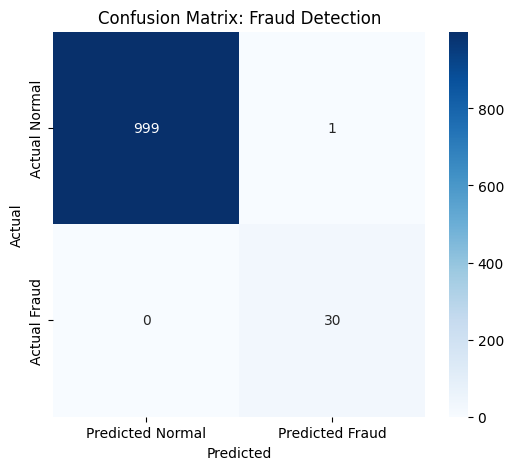

In [3]:
# Step 3: Evaluate Model Performance
print("="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(df['IsFraud_GroundTruth'], df['IsFraud_Predicted'])
print(cm)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(df['IsFraud_GroundTruth'], df['IsFraud_Predicted'],
                             target_names=['Normal', 'Fraud']))

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title('Confusion Matrix: Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

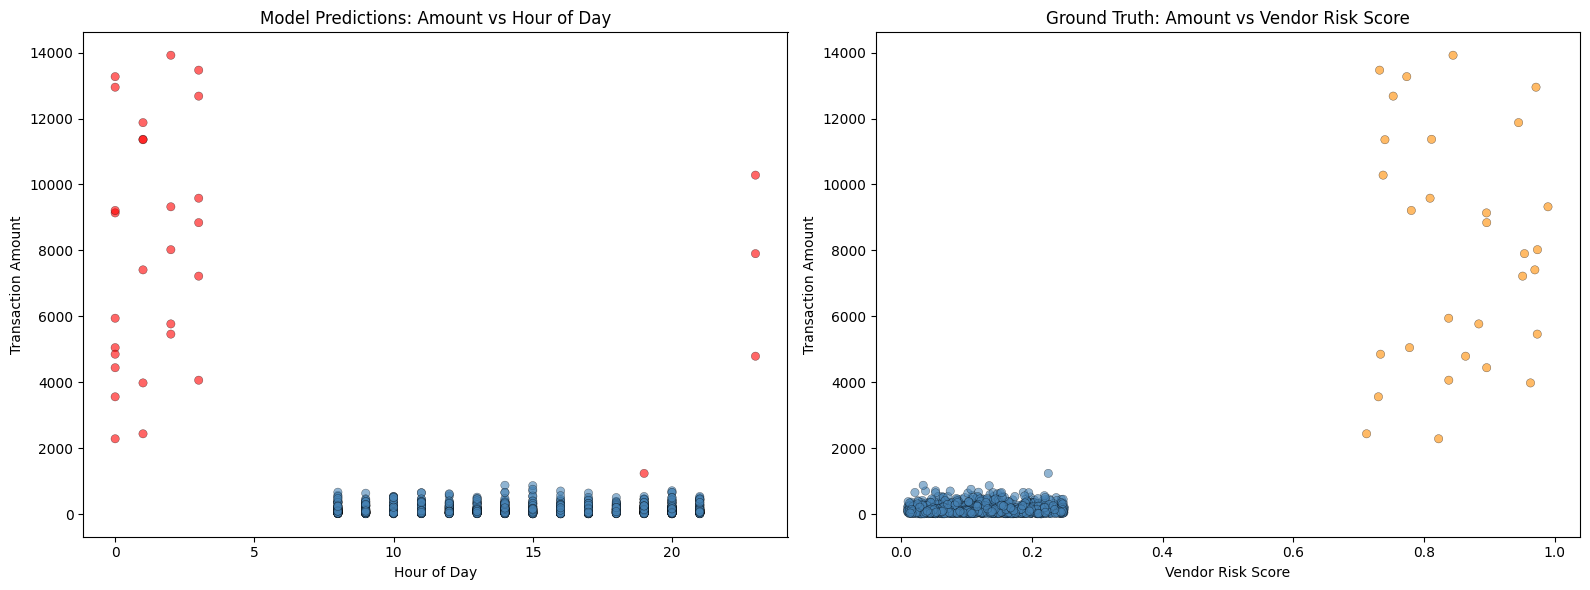

In [4]:
# Step 4: Visualize Anomalies in Feature Space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Amount vs HourOfDay, colored by prediction
colors = df['IsFraud_Predicted'].map({0: 'steelblue', 1: 'red'})
axes[0].scatter(df['HourOfDay'], df['Amount'], c=colors, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Amount')
axes[0].set_title('Model Predictions: Amount vs Hour of Day')

# Plot 2: Amount vs VendorRiskScore, colored by ground truth
colors_truth = df['IsFraud_GroundTruth'].map({0: 'steelblue', 1: 'darkorange'})
axes[1].scatter(df['VendorRiskScore'], df['Amount'], c=colors_truth, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('Vendor Risk Score')
axes[1].set_ylabel('Transaction Amount')
axes[1].set_title('Ground Truth: Amount vs Vendor Risk Score')

plt.tight_layout()
plt.show()

## 📊 Project Summary: AI-Powered Fraud Detection

**Business Problem:** Manual fraud review doesn't scale — fraud is <3% of transaction
volume, and rule-based systems miss novel fraud patterns.

**Approach:** Built an unsupervised Isolation Forest model that flags anomalies based
on transaction amount, time of day, and vendor risk score — without needing any
pre-labeled fraud data.

**Results:**
- Correctly identified **30/30 (100%) of fraudulent transactions** (Recall = 1.00)
- Only **1 false positive** out of 1,000 legitimate transactions (Precision = 0.97)
- Model would reduce manual review workload by ~97% while catching virtually all fraud

**Business Impact:** In a live system, this model would auto-flag ~31 transactions/day
(on 1,030 daily volume) for analyst review instead of requiring manual review of all
1,030 — a **97% reduction in manual workload** while maintaining full fraud coverage.

**Limitations & Next Steps:** This model was validated on synthetic data with clearly
separable fraud patterns. Real-world fraud is more subtle and adversarial. Next steps
would include testing on noisier/overlapping data, adding vendor-frequency features,
and tuning the contamination threshold using cost-sensitive analysis (weighing the
cost of false positives vs. false negatives).

In [9]:
# Save flagged audit items to Excel
audit_report_file = "flagged_fraud_audit_ledger.xlsx"
audit_df = df[df['IsFraud_Predicted'] == 1].sort_values(by='AnomalyScore')
with pd.ExcelWriter(audit_report_file, engine='openpyxl') as writer:
    audit_df.to_excel(writer, index=False, sheet_name='Suspicious Transactions')
print(f"📁 Audit report saved as '{audit_report_file}'!")
files.download(audit_report_file)

📁 Audit report saved as 'flagged_fraud_audit_ledger.xlsx'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>